<a href="https://colab.research.google.com/github/Yohaan20/Solar-Microgrid-Texas/blob/main/week1_solar_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pvlib geopandas folium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
!pip install pvlib geopandas folium



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 70.5 MB/s eta 0:00:00


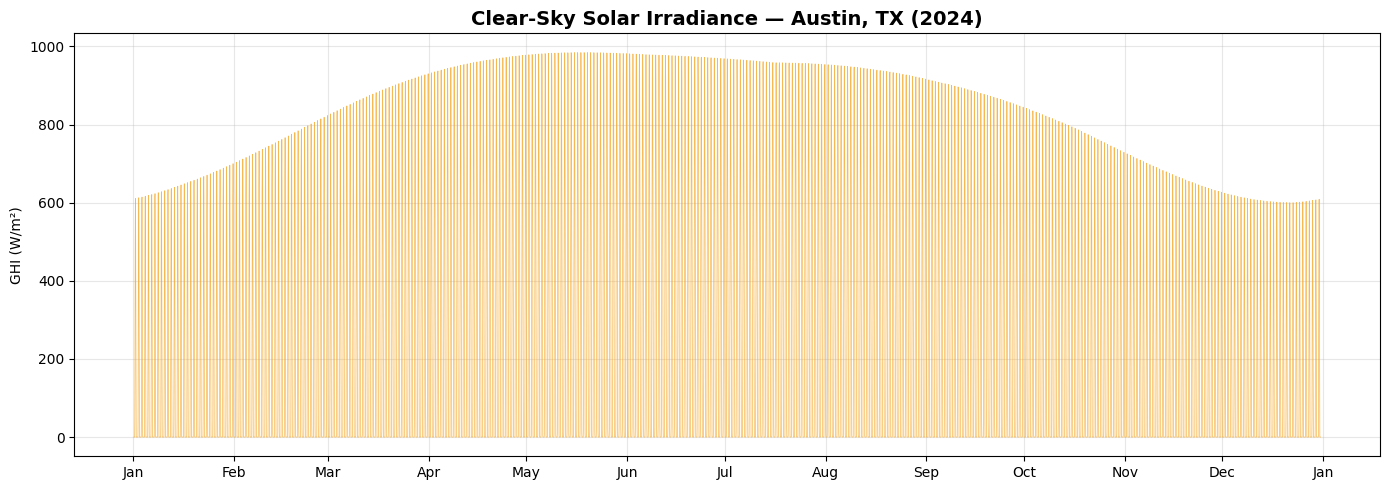

In [2]:
import pvlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Austin, TX coordinates
location = pvlib.location.Location(
    latitude=30.2672, longitude=-97.7431,
    tz='US/Central', altitude=149,
    name='Austin, TX'
)

# Hourly timestamps for all of 2024
times = pd.date_range('2024-01-01', '2024-12-31', freq='1h', tz='US/Central')

# Calculate clear-sky solar irradiance
clearsky = location.get_clearsky(times)

# Plot it
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(clearsky.index, clearsky['ghi'], color='#F5A623', linewidth=0.5, alpha=0.8)
ax.set_title('Clear-Sky Solar Irradiance — Austin, TX (2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('GHI (W/m²)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import pvlib
import pandas as pd
import matplotlib.pyplot as plt

# 5 Texas cities
cities = {
    'Austin':   (30.2672, -97.7431),
    'Houston':  (29.760,  -95.369),
    'Dallas':   (32.776,  -96.797),
    'Lubbock':  (33.578,  -101.855),
    'El Paso':  (31.761,  -106.485),
}

# Pull data using pvlib's built-in NASA POWER function
# This handles all the API calls and parsing automatically
all_data = {}
for city, (lat, lon) in cities.items():
    print(f'Fetching {city}...')
    df, meta = pvlib.iotools.get_nasa_power(
        latitude=lat,
        longitude=lon,
        start='2023-01-01',
        end='2023-12-31',
        parameters=['ghi', 'temp_air'],
        community='re',
        map_variables=True
    )
    df['city'] = city
    all_data[city] = df
    print(f'  Got {len(df)} hours of data')

combined = pd.concat(all_data.values())
print('\nAverage GHI by city (Wh/m²):')
print(combined.groupby('city')['ghi'].mean().sort_values(ascending=False))

Fetching Austin...
  Got 8760 hours of data
Fetching Houston...
  Got 8760 hours of data
Fetching Dallas...
  Got 8760 hours of data
Fetching Lubbock...
  Got 8760 hours of data
Fetching El Paso...
  Got 8760 hours of data

Average GHI by city (Wh/m²):
city
El Paso    246.482360
Lubbock    227.025600
Austin     203.905558
Dallas     198.527918
Houston    197.626002
Name: ghi, dtype: float64


In [13]:
print('Shape:', combined.shape)
print('\nMissing values:')
print(combined.isnull().sum())
print('\nPreview:')
combined.head(10)

Shape: (43800, 3)

Missing values:
ghi         0
temp_air    0
city        0
dtype: int64

Preview:


,ghi,temp_air,city
2023-01-01 00:00:00+00:00,0.0,16.12,Austin
2023-01-01 01:00:00+00:00,0.0,15.68,Austin
2023-01-01 02:00:00+00:00,0.0,14.87,Austin
2023-01-01 03:00:00+00:00,0.0,13.67,Austin
2023-01-01 04:00:00+00:00,0.0,12.87,Austin
2023-01-01 05:00:00+00:00,0.0,12.19,Austin
2023-01-01 06:00:00+00:00,0.0,11.65,Austin
2023-01-01 07:00:00+00:00,0.0,11.22,Austin
2023-01-01 08:00:00+00:00,0.0,10.68,Austin
2023-01-01 09:00:00+00:00,0.0,10.04,Austin


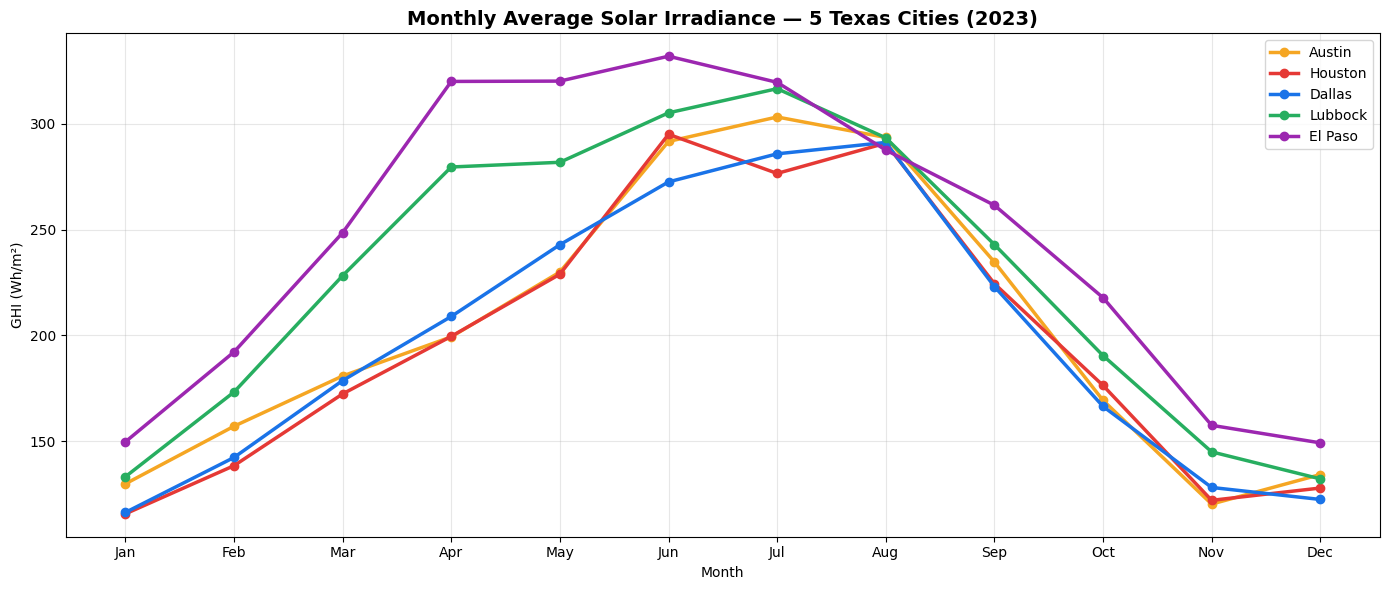

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#F5A623', '#E53935', '#1A73E8', '#27AE60', '#9C27B0']
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

for i, city in enumerate(cities.keys()):
    city_df = combined[combined['city'] == city]
    # Average GHI by month
    monthly = city_df['ghi'].resample('ME').mean()
    ax.plot(months, monthly.values, marker='o', linewidth=2.5,
            color=colors[i], label=city, markersize=6)

ax.set_title('Monthly Average Solar Irradiance — 5 Texas Cities (2023)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('GHI (Wh/m²)')
ax.set_xlabel('Month')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()